In [3]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig
from PIL import Image
import numpy as np


CHECKPOINT_PATH = "Models/vit_crop/checkpoint-32110"
config = ViTConfig.from_pretrained(CHECKPOINT_PATH, output_attentions=True)

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH, config=config)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

Model loaded from Models/vit_crop/checkpoint-32110
Using device: mps


In [4]:
id_to_class = inference_model.config.id2label
class_to_id = inference_model.config.label2id
print(f"Number of classes: {len(id_to_class)}")
print(f"Classes loaded from model configuration")

Number of classes: 60
Classes loaded from model configuration


In [5]:
def predict_fn(images):
    batch_images = []
    for img in images:
        pil_img = Image.fromarray(img.astype('uint8'), 'RGB')
        batch_images.append(pil_img)
        
    inputs = inference_processor(images=batch_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()


In [7]:
def generate_grad_rollout(model, processor, pil_image, target_class_id):

    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    model.eval() 
    outputs = model(**inputs)
    logits = outputs.logits
    attentions = outputs.attentions 
    
    target_logit = logits[0, target_class_id]
    
    model.zero_grad()
    grads = torch.autograd.grad(target_logit, attentions, retain_graph=True, allow_unused=True)
    
    with torch.no_grad():
        num_tokens = attentions[0].shape[-1]
        rollout = torch.eye(num_tokens, device=device) 
        
        for i in range(len(attentions)):
            A_l = attentions[i] 
            G_l = grads[i]      
            
            if G_l is None:
                continue
            
            A_l = A_l.squeeze(0) 
            G_l = G_l.squeeze(0) 
            
            alpha = torch.mean(G_l, dim=(-1, -2))    
            alpha = torch.nn.functional.relu(alpha) 
            
            alpha_sum = torch.sum(alpha)
            if alpha_sum > 0:
                alpha = alpha / alpha_sum
            else:
                alpha = torch.ones_like(alpha) / alpha.shape[0]

            A_l_avg = torch.einsum('h,hsd->sd', alpha, A_l) 
            
            I = torch.eye(num_tokens, device=device)
            A_l_avg = A_l_avg + I
            
            A_l_avg = A_l_avg / A_l_avg.sum(dim=-1, keepdim=True)
            
            rollout = torch.matmul(A_l_avg, rollout)
            
    cls_attention_map = rollout[0, 1:] 
    num_patches_side = int(cls_attention_map.shape[0]**0.5)
    heatmap = cls_attention_map.reshape(num_patches_side, num_patches_side).cpu().numpy()
    
    return heatmap

In [6]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.15) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [8]:
graph = Neo4jGraph(url="neo4j://127.0.0.1:7687", username=os.getenv("NEO4J_USER"), password=os.getenv("NEO4J_PASSWORD"), enhanced_schema=True)

In [9]:
from langchain_neo4j.chains.graph_qa.cypher import GraphCypherQAChain

llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

cypher_chain = GraphCypherQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    verbose=True,
    allow_dangerous_requests=True,    
)

In [22]:
graph.refresh_schema()
print(graph.schema)

Node properties:
- **Entity**
  - `name`: STRING Example: "Fruit lesions"
Relationship properties:

The relationships:
(:Entity)-[:AFFECTS]->(:Entity)
(:Entity)-[:PRESENTS]->(:Entity)
(:Entity)-[:TREATED_BY]->(:Entity)
(:Entity)-[:CAUSED_BY]->(:Entity)


Predicted class: 'Rice,Leaf Blight' (ID: 36)


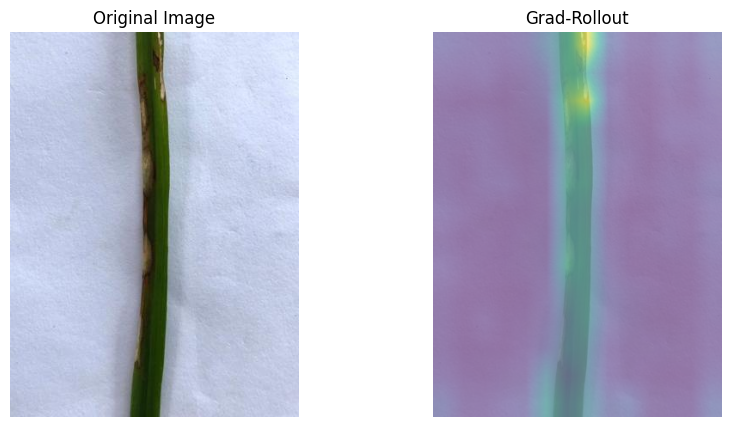

Disease: Leaf Blight, Crop: Rice


> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (disease:Entity {name: "Leaf Blight"})-[:PRESENTS]->(symptom:Entity)
RETURN symptom.name
Full Context:
[{'symptom.name': 'Water-soaked dark green blight'}, {'symptom.name': 'Yellow-brown areas'}]

> Finished chain.
Water-soaked dark green blight, Yellow-brown areas are the symptoms of this disease.


In [36]:
YOUR_IMAGE_PATH_HERE = "dataset/images/Rice,Leaf Blight/plant_123491.jpg" 
YOUR_QUERY_HERE = "What are the symptoms of this disease?"

try:
    image_pil = Image.open(YOUR_IMAGE_PATH_HERE).convert("RGB")
    image_np = np.array(image_pil)

    probs = predict_fn([image_np])
    predicted_class_id = np.argmax(probs[0])
    predicted_class_name = id_to_class[predicted_class_id]
    print(f"Predicted class: '{predicted_class_name}' (ID: {predicted_class_id})")

    heatmap = generate_grad_rollout(
        inference_model, 
        inference_processor, 
        image_pil, 
        predicted_class_id
    )
    
    import matplotlib.pyplot as plt
    import cv2
    
    img_size = inference_processor.size['height']
    heatmap_resized = cv2.resize(heatmap, (image_pil.width, image_pil.height))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image_pil)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-Rollout")
    plt.imshow(image_pil, alpha=0.5)
    plt.imshow(heatmap_resized, cmap='viridis', alpha=0.5)
    plt.axis('off')
    plt.show()

    crop, dis = predicted_class_name.split(',')
    print(f"Disease: {dis}, Crop: {crop}")
    output = cypher_chain.invoke(YOUR_QUERY_HERE + f"Data from image: Disease: {dis}' and Crop: {crop}'")
    print(output['result'])

except FileNotFoundError:
    print(f"Error: Image file not found at '{YOUR_IMAGE_PATH_HERE}'")
except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure your image file is a valid format (JPG, PNG, etc.)")